In [1]:
import sys
import os

# Add the folder and subfolder to the system path
sys.path.append(os.path.abspath(os.path.join('../../')))

# Now you can import your module
# from your_module import your_function

# Inport data from geopandas

In [2]:
import numpy as np
import pandas as pd

parent_dir = "/home/biazzin/git/mimesis/data/ourdata/copernicus_ecdc/"
parent_dir = "../../data/"
year = "2020"
df = pd.read_csv(parent_dir + f'albopictus_presence_absence_ecdc_copernicus_{year}.zip')
#df_suitable = df[df['Suitable'] == 1]  # Select only the suitable records
df_suitable = df
df_Presence_Absence = (df_suitable[(df_suitable["presence_numeric"] == 1) | (df_suitable["presence_numeric"] == 0)]).copy()
df_Presence_Absence["NUTS3_Code"] = df_Presence_Absence["LocationCode"]

In [3]:
# set presence absence to 1 if suitable is 1, otherwise set to 0
df_Presence_Absence["Presence_Absence"] = ((df_Presence_Absence['presence_numeric'] == 1) & (df_Presence_Absence['Suitable'] == 1)).astype(int)

# Check data and remove points set as absence close to points set as presence

<Axes: >

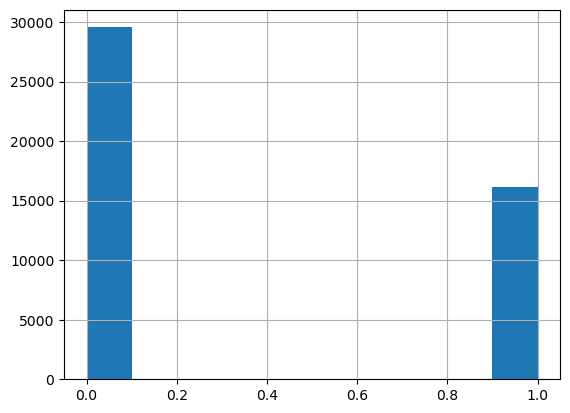

In [4]:
import matplotlib.pyplot as plt
df_Presence_Absence["Presence_Absence"].hist()

In [5]:
import geopandas as gpd

df_gdf = gpd.GeoDataFrame(df_Presence_Absence, geometry=gpd.points_from_xy(df_Presence_Absence['longitude'], df_Presence_Absence['latitude']))

<Axes: >

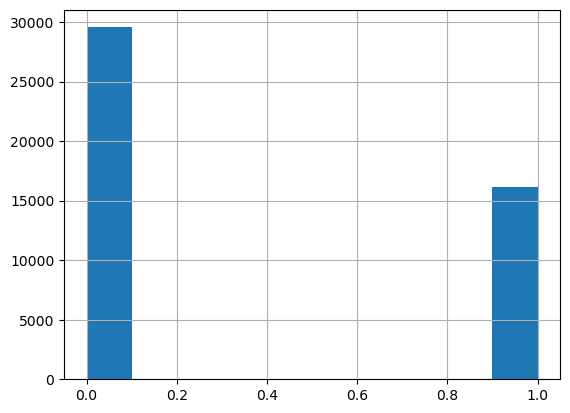

In [6]:
df_Presence_Absence = df_gdf.copy()

df_Presence_Absence["Presence_Absence"].hist()

In [7]:
import AIedes.data_loader.classificator_data_loader
import importlib

from AIedes.data_loader.classificator_data_loader import normalize_temperature_df, normalize_precipitation_df

df_Presence_Absence = normalize_temperature_df(df_Presence_Absence)
df_Presence_Absence = normalize_precipitation_df(df_Presence_Absence)

temp_cols ['temp_Jan_C', 'temp_Feb_C', 'temp_Mar_C', 'temp_Apr_C', 'temp_May_C', 'temp_Jun_C', 'temp_Jul_C', 'temp_Aug_C', 'temp_Sep_C', 'temp_Oct_C', 'temp_Nov_C', 'temp_Dec_C']
Temperature columns normalized with mean and std.
precip_cols ['precip_Jan_mm', 'precip_Feb_mm', 'precip_Mar_mm', 'precip_Apr_mm', 'precip_May_mm', 'precip_Jun_mm', 'precip_Jul_mm', 'precip_Aug_mm', 'precip_Sep_mm', 'precip_Oct_mm', 'precip_Nov_mm', 'precip_Dec_mm']
Precipitation columns normalized with mean and std.


In [8]:
features = ['temp_Jan_C', 'temp_Feb_C', 'temp_Mar_C', 'temp_Apr_C', 
            'temp_May_C', 'temp_Jun_C', 'temp_Jul_C', 'temp_Aug_C', 
            'temp_Sep_C', 'temp_Oct_C', 'temp_Nov_C', 'temp_Dec_C', 'precip_Jan_mm',
            'precip_Feb_mm', 'precip_Mar_mm', 'precip_Apr_mm',
            'precip_May_mm', 'precip_Jun_mm', 'precip_Jul_mm', 'precip_Aug_mm',
            'precip_Sep_mm', 'precip_Oct_mm', 'precip_Nov_mm', 'precip_Dec_mm']
datas = {}
df_years = {}

data = df_Presence_Absence[features + ["Presence_Absence"]].to_numpy()


In [9]:
import importlib
import torch
# set threads to 1 to avoid issues with multiprocessing in Jupyter notebooks
torch.set_num_threads(4)
# set number of cpu threads to 1 to avoid issues with multiprocessing in Jupyter notebooks
#torch.set_num_interop_threads(4)

In [10]:
import importlib
from locale import normalize
from AIedes.data_loader.classificator_data_loader import get_data_loaders
# Get data loaders and input size
batch_size = 1024
learning_rate = 0.002
random_seed = 42

train_loaders = {}
test_loaders = {}
train_loader_order, test_loader_order, input_size_order, _ = get_data_loaders(
    data=data, batch_size = batch_size, test_ratio = 1, random_seed = random_seed, shuffle = False, normalize=False
)



/home/biazzin/git/AIedes/src/AIedes/data_loader/classificator_data_loader.py:56: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.y = torch.tensor(y, dtype=torch.float)  # Labels for classification


# Function like the paper

In [11]:
import pandas as pd
import pickle
from AIedes.train.classificator_train    import run_model
from AIedes.evaluation.classificator_evaluate import evaluate_model_nuts3, evaluate_model

# read all the result and models files that have "temp_tp" in the name
# list in the current directory that have "temp_tp" in the name
import glob
results_files = glob.glob("../res/results_and_models*temp_tp.pkl")
print("Results files found:", results_files)
res_df = []
for name_file in results_files:
    print("Loading file:", name_file)
    with open(name_file, 'rb') as f:
        results = pickle.load(f)
    #print("Results loaded:", results)
    res_df.append(results)
res_df = pd.concat(res_df, ignore_index=True)
res_df

Results files found: ['../res/results_and_models_2020_[]_temp_tp.pkl', '../res/results_and_models_2020_[10, 10, 10]_temp_tp.pkl', '../res/results_and_models_2020_[10, 10]_temp_tp.pkl', '../res/results_and_models_2020_[10]_temp_tp.pkl', '../res/results_and_models_2020_[20, 20, 20]_temp_tp.pkl', '../res/results_and_models_2020_[20, 20]_temp_tp.pkl', '../res/results_and_models_2020_[20]_temp_tp.pkl', '../res/results_and_models_2020_[30, 30, 30]_temp_tp.pkl', '../res/results_and_models_2020_[30, 30]_temp_tp.pkl', '../res/results_and_models_2020_[30]_temp_tp.pkl', '../res/results_and_models_2020_[40, 40, 40]_temp_tp.pkl', '../res/results_and_models_2020_[40, 40]_temp_tp.pkl', '../res/results_and_models_2020_[50, 50, 50]_temp_tp.pkl', '../res/results_and_models_2020_[50, 50]_temp_tp.pkl']
Loading file: ../res/results_and_models_2020_[]_temp_tp.pkl
Loading file: ../res/results_and_models_2020_[10, 10, 10]_temp_tp.pkl
Loading file: ../res/results_and_models_2020_[10, 10]_temp_tp.pkl
Loading fi

,hidden_layers,ACC_test_list,TPR_test_list,TNR_test_list,FPR_test_list,FNR_test_list,MEAN_fold,MEAN_ACC_test,MEAN_TPR_test,MEAN_TNR_test,...,type,num_params,num_epochs,test_ratio,val_ratio,learning_rate,random_seed,input_variables,input_size,model
0,[],"[90.15855658829962, 90.41006014215418, 89.7648...","[0.8669965975873801, 0.8669965975873801, 0.861...","[0.9205006765899865, 0.9243910690121786, 0.917...","[0.07949932341001353, 0.07560893098782138, 0.0...","[0.13300340241261985, 0.13300340241261985, 0.1...",3.0,89.913382,0.860801,0.920095,...,NN,25,500,0.15,0.0,0.002,42,"[temp_Jan_C, temp_Feb_C, temp_Mar_C, temp_Apr_...",24,[AIedesClassificator(\n (layers): ModuleList(...
1,"[10, 10, 10]","[95.1776927282668, 95.8337889557135, 95.921268...","[0.9350448499845345, 0.9455613980822766, 0.957...","[0.9609269282814614, 0.9653247631935047, 0.960...","[0.03907307171853856, 0.034675236806495265, 0....","[0.06495515001546551, 0.05443860191772348, 0.0...",3.0,95.870879,0.951435,0.962686,...,NN,481,500,0.15,0.0,0.002,42,"[temp_Jan_C, temp_Feb_C, temp_Mar_C, temp_Apr_...",24,[AIedesClassificator(\n (layers): ModuleList(...
2,"[10, 10]","[95.03553854565337, 96.12903225806451, 95.0246...","[0.9486545004639654, 0.9467986390349521, 0.924...","[0.9512855209742895, 0.9692151556156969, 0.964...","[0.04871447902571042, 0.030784844384303112, 0....","[0.05134549953603464, 0.05320136096504794, 0.0...",3.0,95.468471,0.944507,0.960250,...,NN,371,500,0.15,0.0,0.002,42,"[temp_Jan_C, temp_Feb_C, temp_Mar_C, temp_Apr_...",24,[AIedesClassificator(\n (layers): ModuleList(...
3,[10],"[95.46200109349371, 94.08419901585566, 93.2312...","[0.9461800185586143, 0.9254562326012991, 0.920...","[0.9592354533152909, 0.949255751014885, 0.9385...","[0.040764546684709066, 0.05074424898511502, 0....","[0.05381998144138571, 0.0745437673987009, 0.07...",3.0,94.202149,0.932875,0.947023,...,NN,261,500,0.15,0.0,0.002,42,"[temp_Jan_C, temp_Feb_C, temp_Mar_C, temp_Apr_...",24,[AIedesClassificator(\n (layers): ModuleList(...
4,"[20, 20, 20]","[96.81793329688354, 97.64898851831602, 97.1350...","[0.9774203526136716, 0.9768017321373338, 0.980...","[0.963125845737483, 0.976319350473613, 0.96650...","[0.03687415426251692, 0.02368064952638701, 0.0...","[0.022579647386328488, 0.023198267862666256, 0...",3.0,97.279318,0.975563,0.971279,...,NN,1361,500,0.15,0.0,0.002,42,"[temp_Jan_C, temp_Feb_C, temp_Mar_C, temp_Apr_...",24,[AIedesClassificator(\n (layers): ModuleList(...
5,"[20, 20]","[97.255330781848, 97.255330781848, 97.12411153...","[0.9678317352304361, 0.968141045468605, 0.9644...","[0.9751353179972937, 0.9749661705006766, 0.974...","[0.02486468200270636, 0.02503382949932341, 0.0...","[0.03216826476956387, 0.03185895453139499, 0.0...",3.0,97.071547,0.962385,0.975271,...,NN,941,500,0.15,0.0,0.002,42,"[temp_Jan_C, temp_Feb_C, temp_Mar_C, temp_Apr_...",24,[AIedesClassificator(\n (layers): ModuleList(...
6,[20],"[95.80098414434117, 94.87151448879169, 96.1180...","[0.9353541602227033, 0.9403031240334055, 0.957...","[0.9703991880920162, 0.9533152909336942, 0.963...","[0.029600811907983762, 0.04668470906630582, 0....","[0.06464583977729663, 0.059696875966594495, 0....",3.0,95.536246,0.947167,0.959844,...,NN,521,500,0.15,0.0,0.002,42,"[temp_Jan_C, temp_Feb_C, temp_Mar_C, temp_Apr_...",24,[AIedesClassificator(\n (layers): ModuleList(...
7,"[30, 30, 30]","[97.71459814106069, 97.26626571897212, 97.9770...","[0.9508196721311475, 0.9452520878441076, 0.965...","[0.9915426251691475, 0.9876522327469553, 0.987...","[0.008457374830852503, 0.012347767253044655, 0...","[0.04918032786885246, 0.05474791215589236, 0.0...",3.0,97.627068,0.955333,0.987720,...,NN,2641,500,0.15,0.0,0.002,42,"[temp_Jan_C, temp_Feb_C, temp_Mar_C, temp_Apr_...",24,[AIedesClassificator(\n (layers): ModuleList(...
8,"[30, 30]","[97.38655002733735, 97.50683433570256, 97.3865...","[0.9582431178472007, 0.9703062171357872, 0.984...","[0.9824086603518268, 0.9776725304465493, 0.967...","[0.017591339648173207, 0.022327469553450607, 0...","[

In [12]:
res_df["CSI_test"] = res_df.apply(
    lambda row: row["MEAN_TPR_test"] / (row["MEAN_TPR_test"] + row["MEAN_FNR_test"] + row["MEAN_FPR_test"]) if (row["MEAN_TPR_test"] + row["MEAN_FNR_test"] + row["MEAN_FPR_test"]) > 0 else 0,
    axis=1
)

In [17]:
res_df[["hidden_layers", "MEAN_ACC_test", "ACC", "CSI_test"]]

,hidden_layers,MEAN_ACC_test,ACC,CSI_test
0,[],89.913382,89.987753,0.797108
1,"[10, 10, 10]",95.870879,95.337241,0.917211
2,"[10, 10]",95.468471,95.555944,0.908399
3,[10],94.202149,95.000437,0.885941
4,"[20, 20, 20]",97.279318,98.473449,0.948325
5,"[20, 20]",97.071547,97.594261,0.939160
6,[20],95.536246,95.967107,0.910601
7,"[30, 30, 30]",97.627068,98.888986,0.943744
8,"[30, 30]",97.460839,98.355349,0.949385
9,[30],96.021784,96.461377,0.922890


In [14]:
import torch

def compute_suitability_index(model_, data_loader_):
    with torch.no_grad():
        res = []
        for data in data_loader_:
            inputs, labels = data
            outputs = torch.sigmoid(model_(inputs))
            res.append(outputs)
    return torch.cat(res)

In [15]:
res_df.hidden_layers = res_df.hidden_layers.apply(lambda x: str(x))

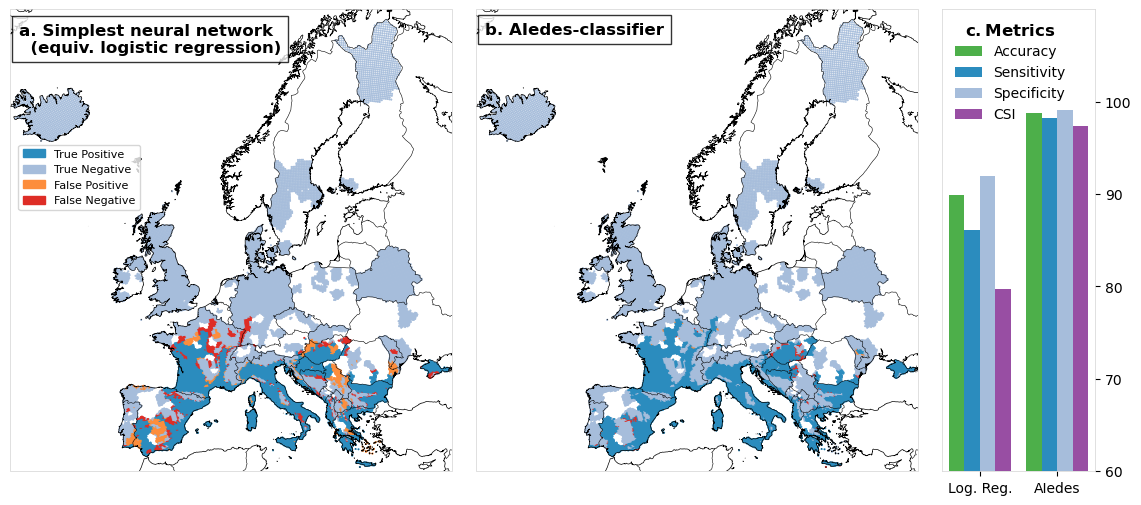

In [16]:
import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np

# Prepare GeoDataFrame
df_Presence_Absence = gpd.GeoDataFrame(
    df_Presence_Absence.copy(), 
    geometry='geometry', 
    crs='EPSG:4326'
)

# Define categories and colors
categories = ['True Positive', 'True Negative', 'False Positive', 'False Negative']
colors = ['#2b8cbe', '#a6bddb', '#fd8d3c', '#de2d26']
colormap = ListedColormap(colors)

# Calculate common extent for both maps
minx, miny, maxx, maxy = df_Presence_Absence.total_bounds
pad = 0.5
extent = [minx - pad, maxx + pad, miny - pad, maxy + pad]

# Create figure with two maps and a bar chart
fig = plt.figure(figsize=(14, 6))
gs = fig.add_gridspec(1, 3, width_ratios=[3, 3, 1], wspace=0.02)
axes = [fig.add_subplot(gs[0, i], projection=ccrs.Mercator()) for i in range(2)]
ax_bar = fig.add_subplot(gs[0, 2])

# Configure map axes
for ax in axes:
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.set_anchor('W')
    ax.coastlines('10m', linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4)
    ax.add_feature(cfeature.LAND, facecolor='white')
    ax.add_feature(cfeature.OCEAN, facecolor='white')


def plot_predictions(df, ax, markersize=2, alpha=0.8):
    """Plot prediction results on map"""
    df_valid = df[df.geometry.is_valid].copy()
    
    # Classify results
    df_valid['results'] = np.select(
        [
            (df_valid['Presence_Absence'] == 1) & (df_valid['predicted'] == 1),
            (df_valid['Presence_Absence'] == 0) & (df_valid['predicted'] == 0),
            (df_valid['Presence_Absence'] == 0) & (df_valid['predicted'] == 1),
            (df_valid['Presence_Absence'] == 1) & (df_valid['predicted'] == 0),
        ],
        categories,
        default='NA'
    )
    
    # Map categories to numeric values for colormap
    cat_to_idx = {c: i for i, c in enumerate(categories)}
    cvals = df_valid['results'].map(cat_to_idx).to_numpy()
    
    # Use scatter with proper transform (same as first version)
    ax.scatter(
        df_valid.geometry.x.to_numpy(),
        df_valid.geometry.y.to_numpy(),
        c=cvals,
        s=markersize,
        cmap=colormap,
        alpha=alpha,
        edgecolors='none',
        transform=ccrs.PlateCarree()
    )


# Model 1: Logistic Regression (no hidden layers)
model_info_lr = res_df[res_df["hidden_layers"] == "[]"]
net_lr = model_info_lr["model"].values[0][0]

df_lr = df_Presence_Absence[["Presence_Absence", "geometry", "NUTS3_Code"]].copy()
df_lr["predicted_estim_risk"] = compute_suitability_index(net_lr, test_loader_order).numpy()
df_lr["predicted"] = df_lr["predicted_estim_risk"] > 0.5

plot_predictions(df_lr, axes[0])

axes[0].text(
    0.02, 0.9, "a. Simplest neural network \n  (equiv. logistic regression)",
    transform=axes[0].transAxes,
    fontsize=12, fontweight='bold', 
    va='bottom', ha='left',
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', pad=5)
)

# Model 2: Neural Network with hidden layers
model_info_nn = res_df[res_df["hidden_layers"] == "[50, 50, 50]"]
net_nn = model_info_nn["model"].values[0][0]

df_nn = df_Presence_Absence[["Presence_Absence", "geometry", "NUTS3_Code"]].copy()
df_nn["predicted_estim_risk"] = compute_suitability_index(net_nn, test_loader_order).numpy()
df_nn["predicted"] = df_nn["predicted_estim_risk"] > 0.5

plot_predictions(df_nn, axes[1])

axes[1].text(
    0.02, 0.94, "b. AIedes-classifier",
    transform=axes[1].transAxes,
    fontsize=12, fontweight='bold', 
    va='bottom', ha='left',
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', pad=5)
)

# Multi-metric bar chart
x_labels = ['Log. Reg.', 'AIedes']
x = np.arange(len(x_labels))
width = 0.2

# Extract metric values
accuracy_values = np.array([
    model_info_lr["MEAN_ACC_test"].values[0],
    model_info_nn["MEAN_ACC_test"].values[0]
]) 

tpr_values = np.array([
    model_info_lr["MEAN_TPR_test"].values[0],
    model_info_nn["MEAN_TPR_test"].values[0]
]) * 100

tnr_values = np.array([
    model_info_lr["MEAN_TNR_test"].values[0],
    model_info_nn["MEAN_TNR_test"].values[0]
]) * 100

csi_values = np.array([
    model_info_lr["CSI_test"].values[0],
    model_info_nn["CSI_test"].values[0]
]) * 100

# Plot bars with distinct colors
ax_bar.bar(x - width, accuracy_values, width, label='Accuracy', color="#4daf4a")
ax_bar.bar(x, tpr_values, width, label='Sensitivity', color='#2b8cbe')
ax_bar.bar(x + width, tnr_values, width, label='Specificity', color='#a6bddb')
ax_bar.bar(x + 2 * width, csi_values, width, label='CSI', color="#984ea3")

# Format bar chart
ax_bar.yaxis.set_label_position("right")
ax_bar.yaxis.set_ticks_position("right")
ax_bar.set_xticks(x+0.1)
ax_bar.set_xticklabels(x_labels)
ax_bar.set_ylim(60, 110)
ax_bar.set_yticks([60, 70, 80, 90, 100])
ax_bar.legend(
    loc='upper left', 
    fontsize=10, 
    frameon=False, 
    title=r'$\bf{c. Metrics}$', 
    title_fontsize='12'
)

# Add legend for map categories
patches = [mpatches.Patch(color=c, label=cat) for c, cat in zip(colors, categories)]
fig.legend(
    handles=patches, 
    bbox_to_anchor=(0.127, 0.6), 
    loc='center left', 
    frameon=True, 
    fontsize=8
)

for spine in axes[0].spines.values():
    spine.set_edgecolor('lightgray')
    spine.set_linewidth(0.5)

for spine in axes[1].spines.values():
    spine.set_edgecolor('lightgray')
    spine.set_linewidth(0.5)

for spine in ax_bar.spines.values():
    spine.set_edgecolor('lightgray')
    spine.set_linewidth(0.5)
    
# Save figure
fig.savefig("./comparison_lr_nn.png", dpi=400, bbox_inches='tight')

plt.show()

In [20]:
res_df[["hidden_layers", "MEAN_ACC_test", "MEAN_TPR_test", "MEAN_TNR_test", "CSI_test"]]

,hidden_layers,MEAN_ACC_test,MEAN_TPR_test,MEAN_TNR_test,CSI_test
0,[],89.913382,0.860801,0.920095,0.797108
1,"[10, 10, 10]",95.870879,0.951435,0.962686,0.917211
2,"[10, 10]",95.468471,0.944507,0.960250,0.908399
3,[10],94.202149,0.932875,0.947023,0.885941
4,"[20, 20, 20]",97.279318,0.975563,0.971279,0.948325
5,"[20, 20]",97.071547,0.962385,0.975271,0.939160
6,[20],95.536246,0.947167,0.959844,0.910601
7,"[30, 30, 30]",97.627068,0.955333,0.987720,0.943744
8,"[30, 30]",97.460839,0.972284,0.975880,0.949385
9,[30],96.021784,0.958982,0.960893,0.922890


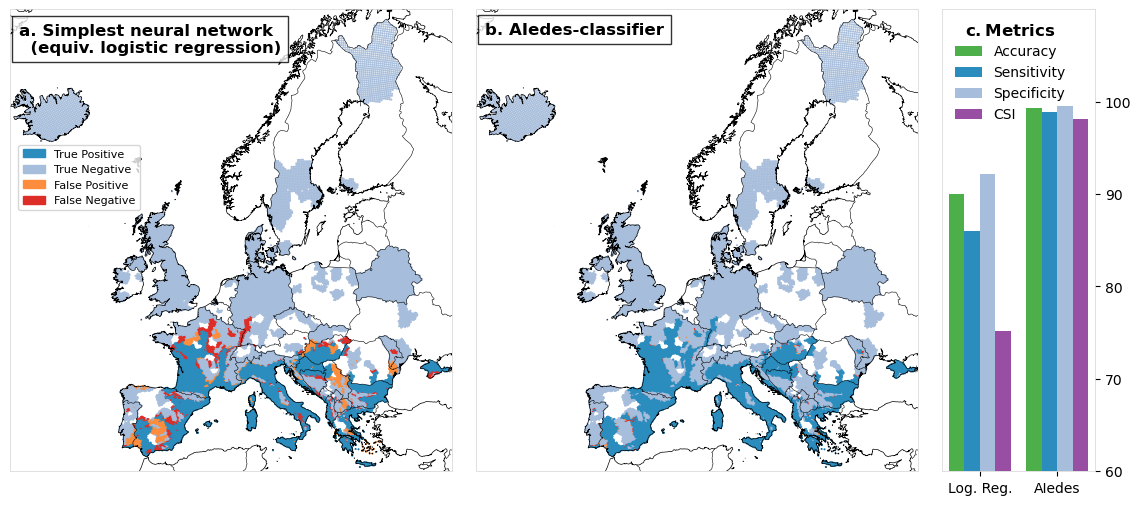

In [18]:
import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np

# Prepare GeoDataFrame
df_Presence_Absence = gpd.GeoDataFrame(
    df_Presence_Absence.copy(), 
    geometry='geometry', 
    crs='EPSG:4326'
)

# Define categories and colors
categories = ['True Positive', 'True Negative', 'False Positive', 'False Negative']
colors = ['#2b8cbe', '#a6bddb', '#fd8d3c', '#de2d26']
colormap = ListedColormap(colors)

# Calculate common extent for both maps
minx, miny, maxx, maxy = df_Presence_Absence.total_bounds
pad = 0.5
extent = [minx - pad, maxx + pad, miny - pad, maxy + pad]

# Create figure with two maps and a bar chart
fig = plt.figure(figsize=(14, 6))
gs = fig.add_gridspec(1, 3, width_ratios=[3, 3, 1], wspace=0.02)
axes = [fig.add_subplot(gs[0, i], projection=ccrs.Mercator()) for i in range(2)]
ax_bar = fig.add_subplot(gs[0, 2])

# Configure map axes
for ax in axes:
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.set_anchor('W')
    ax.coastlines('10m', linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4)
    ax.add_feature(cfeature.LAND, facecolor='white')
    ax.add_feature(cfeature.OCEAN, facecolor='white')


def plot_predictions(df, ax, markersize=2, alpha=0.8):
    """Plot prediction results on map"""
    df_valid = df[df.geometry.is_valid].copy()
    
    # Classify results
    df_valid['results'] = np.select(
        [
            (df_valid['Presence_Absence'] == 1) & (df_valid['predicted'] == 1),
            (df_valid['Presence_Absence'] == 0) & (df_valid['predicted'] == 0),
            (df_valid['Presence_Absence'] == 0) & (df_valid['predicted'] == 1),
            (df_valid['Presence_Absence'] == 1) & (df_valid['predicted'] == 0),
        ],
        categories,
        default='NA'
    )
    
    # Map categories to numeric values for colormap
    cat_to_idx = {c: i for i, c in enumerate(categories)}
    cvals = df_valid['results'].map(cat_to_idx).to_numpy()
    
    # Use scatter with proper transform (same as first version)
    ax.scatter(
        df_valid.geometry.x.to_numpy(),
        df_valid.geometry.y.to_numpy(),
        c=cvals,
        s=markersize,
        cmap=colormap,
        alpha=alpha,
        edgecolors='none',
        transform=ccrs.PlateCarree()
    )

# compute the accuracy specificity sensitivity and csi for both models for the whole dataset
def compute_metrics(df):
    TP = ((df["Presence_Absence"] == 1) & (df["predicted"] == 1)).sum()
    TN = ((df["Presence_Absence"] == 0) & (df["predicted"] == 0)).sum()
    FP = ((df["Presence_Absence"] == 0) & (df["predicted"] == 1)).sum()
    FN = ((df["Presence_Absence"] == 1) & (df["predicted"] == 0)).sum()
    
    accuracy = (TP + TN) / (TP + TN + FP + FN) if (TP + TN + FP + FN) > 0 else 0
    sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
    csi = TP / (TP + FN + FP) if (TP + FN + FP) > 0 else 0
    
    return accuracy, sensitivity, specificity, csi


# Model 1: Logistic Regression (no hidden layers)
model_info_lr = res_df[res_df["hidden_layers"] == "[]"]
net_lr = model_info_lr["model"].values[0][0]

df_lr = df_Presence_Absence[["Presence_Absence", "geometry", "NUTS3_Code"]].copy()
df_lr["predicted_estim_risk"] = compute_suitability_index(net_lr, test_loader_order).numpy()
df_lr["predicted"] = df_lr["predicted_estim_risk"] > 0.5

accuracy_lr, sensitivity_lr, specificity_lr, csi_lr = compute_metrics(df_lr)

plot_predictions(df_lr, axes[0])

axes[0].text(
    0.02, 0.9, "a. Simplest neural network \n  (equiv. logistic regression)",
    transform=axes[0].transAxes,
    fontsize=12, fontweight='bold', 
    va='bottom', ha='left',
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', pad=5)
)

# Model 2: Neural Network with hidden layers
model_info_nn = res_df[res_df["hidden_layers"] == "[40, 40, 40]"]
#model_info_nn = res_df[res_df["hidden_layers"] == "[50, 50]"]
net_nn = model_info_nn["model"].values[0][0]

df_nn = df_Presence_Absence[["Presence_Absence", "geometry", "NUTS3_Code"]].copy()
df_nn["predicted_estim_risk"] = compute_suitability_index(net_nn, test_loader_order).numpy()
df_nn["predicted"] = df_nn["predicted_estim_risk"] > 0.5

plot_predictions(df_nn, axes[1])

axes[1].text(
    0.02, 0.94, "b. AIedes-classifier",
    transform=axes[1].transAxes,
    fontsize=12, fontweight='bold', 
    va='bottom', ha='left',
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', pad=5)
)

# Multi-metric bar chart
x_labels = ['Log. Reg.', 'AIedes']
x = np.arange(len(x_labels))
width = 0.2

accuracy_nn, sensitivity_nn, specificity_nn, csi_nn = compute_metrics(df_nn)

# Extract metric values
accuracy_values = np.array([
    accuracy_lr,
    accuracy_nn
]) * 100

tpr_values = np.array([
    sensitivity_lr,
    sensitivity_nn
]) * 100

tnr_values = np.array([
    specificity_lr,
    specificity_nn
]) * 100

csi_values = np.array([
    csi_lr,
    csi_nn
]) * 100

# Plot bars with distinct colors
ax_bar.bar(x - width, accuracy_values, width, label='Accuracy', color="#4daf4a")
ax_bar.bar(x, tpr_values, width, label='Sensitivity', color='#2b8cbe')
ax_bar.bar(x + width, tnr_values, width, label='Specificity', color='#a6bddb')
ax_bar.bar(x + 2 * width, csi_values, width, label='CSI', color="#984ea3")

# Format bar chart
ax_bar.yaxis.set_label_position("right")
ax_bar.yaxis.set_ticks_position("right")
ax_bar.set_xticks(x+0.1)
ax_bar.set_xticklabels(x_labels)
ax_bar.set_ylim(60, 110)
ax_bar.set_yticks([60, 70, 80, 90, 100])
ax_bar.legend(
    loc='upper left', 
    fontsize=10, 
    frameon=False, 
    title=r'$\bf{c. Metrics}$', 
    title_fontsize='12'
)

# Add legend for map categories
patches = [mpatches.Patch(color=c, label=cat) for c, cat in zip(colors, categories)]
fig.legend(
    handles=patches, 
    bbox_to_anchor=(0.127, 0.6), 
    loc='center left', 
    frameon=True, 
    fontsize=8
)

for spine in axes[0].spines.values():
    spine.set_edgecolor('lightgray')
    spine.set_linewidth(0.5)

for spine in axes[1].spines.values():
    spine.set_edgecolor('lightgray')
    spine.set_linewidth(0.5)

for spine in ax_bar.spines.values():
    spine.set_edgecolor('lightgray')
    spine.set_linewidth(0.5)
    
# Save figure
#fig.savefig("./comparison_lr_nn.png", dpi=400, bbox_inches='tight')

plt.show()

In [19]:
accuracy_nn, specificity_nn, sensitivity_nn, csi_nn

(np.float64(0.993176450004374),
 np.float64(0.9955345060893098),
 np.float64(0.9888641425389755),
 np.float64(0.9808541973490427))